<a href="https://colab.research.google.com/github/badhayearushi-alt/Python---Basic---Projects/blob/main/task_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.datasets import make_blobs

# Create synthetic dataset
X, y = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=0.70,
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])

print(df.head(10))
print("Shape of Dataset:", df.shape)

   Feature1  Feature2
0 -8.033836  6.831299
1 -8.767448 -6.918116
2  6.172741  1.407361
3 -2.783673  7.989826
4 -6.038777 -7.165762
5 -6.298392 -7.479368
6 -7.046269  7.256281
7 -6.690307 -6.915276
8  3.892545  1.873504
9 -7.317000 -6.861846
Shape of Dataset: (500, 2)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print(pd.DataFrame(X_scaled, columns=df.columns).head())

   Feature1  Feature2
0 -0.888474  0.629907
1 -1.028908 -1.562875
2  1.831069 -0.235113
3  0.116557  0.814671
4 -0.506563 -1.602370


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df.head(10))

   Feature1  Feature2  Cluster
0 -8.033836  6.831299        1
1 -8.767448 -6.918116        2
2  6.172741  1.407361        0
3 -2.783673  7.989826        1
4 -6.038777 -7.165762        2
5 -6.298392 -7.479368        2
6 -7.046269  7.256281        1
7 -6.690307 -6.915276        2
8  3.892545  1.873504        0
9 -7.317000 -6.861846        2


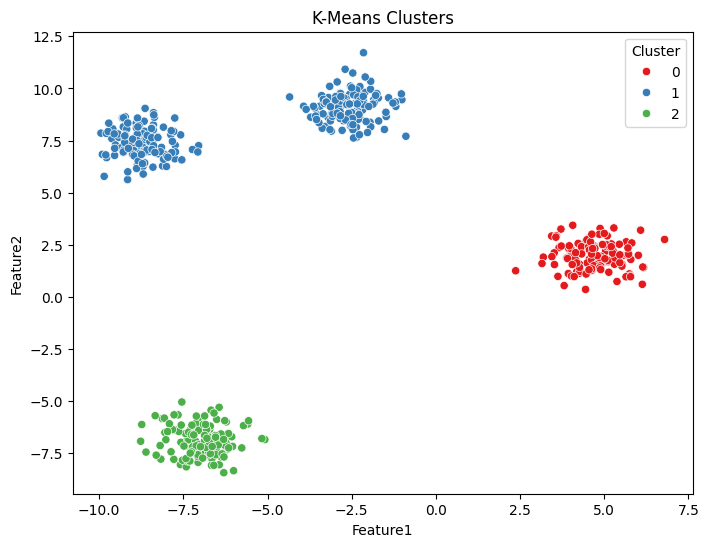

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Feature1",
    y="Feature2",
    hue="Cluster",
    data=df,
    palette="Set1"
)

plt.title("K-Means Clusters")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

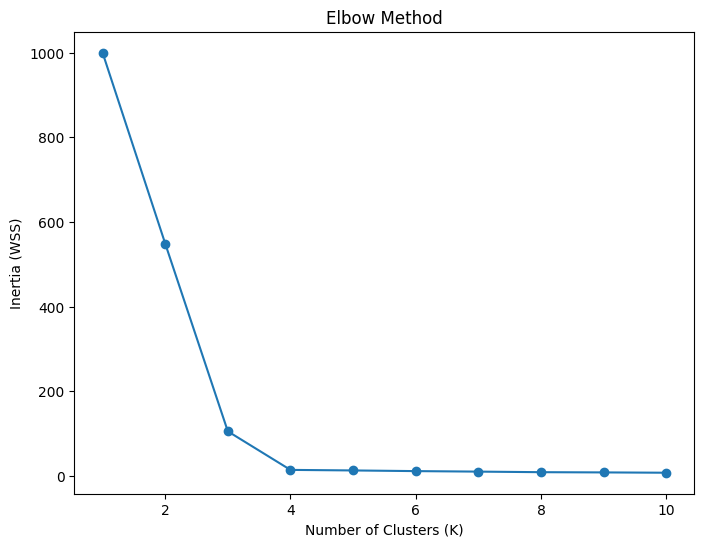

Optimal K looks around 4


In [ ]:
wss = []

for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    wss.append(model.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1,11), wss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WSS)")
plt.show()

print("Optimal K looks around 4")

In [ ]:
kmeans_final = KMeans(n_clusters=4, random_state=42)

df["Final_Cluster"] = kmeans_final.fit_predict(X_scaled)

print(df["Final_Cluster"].value_counts())

Final_Cluster
1    125
2    125
0    125
3    125
Name: count, dtype: int64


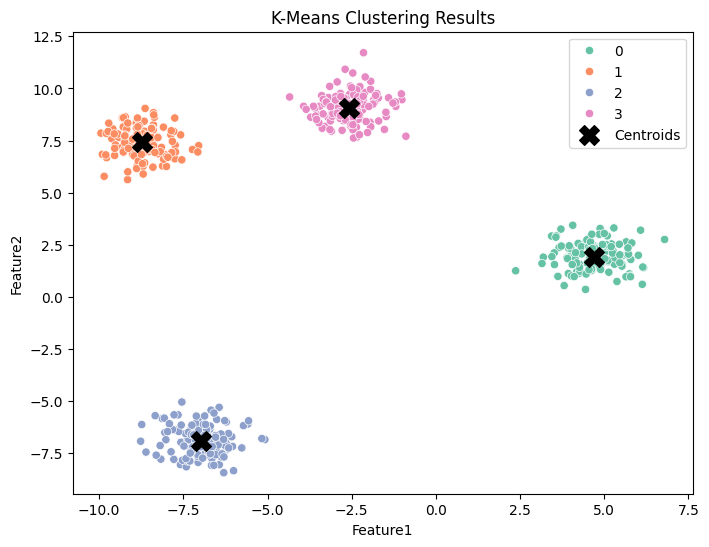

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Feature1",
    y="Feature2",
    hue="Final_Cluster",
    data=df,
    palette="Set2"
)

centers = scaler.inverse_transform(kmeans_final.cluster_centers_)

plt.scatter(
    centers[:,0],
    centers[:,1],
    s=200,
    c="black",
    marker="X",
    label="Centroids"
)

plt.title("K-Means Clustering Results")
plt.legend()
plt.show()

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()

iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

scaler = StandardScaler()

iris_scaled = scaler.fit_transform(iris_df)

kmeans = KMeans(n_clusters=3, random_state=42)

iris_df["Cluster"] = kmeans.fit_predict(iris_scaled)

print(iris_df.head())

print("\nCluster Counts")

print(iris_df["Cluster"].value_counts())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  

Cluster Counts
Cluster
0    96
1    33
2    21
Name: count, dtype: int64


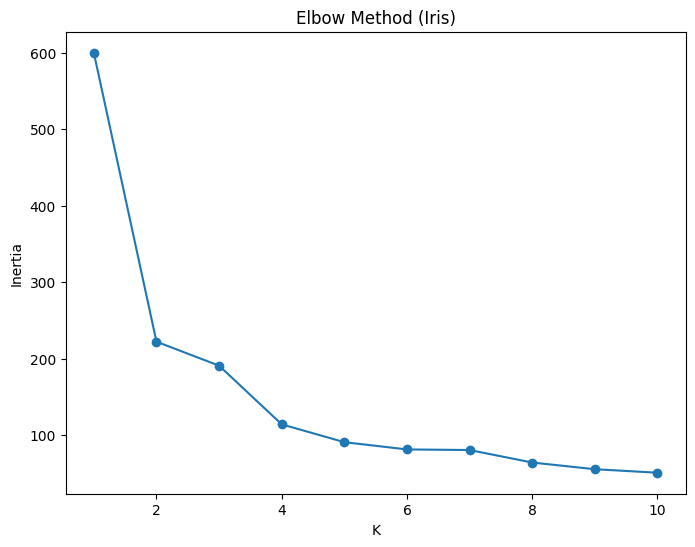

FinalCluster
0    96
1    33
2    21
Name: count, dtype: int64


In [ ]:
wss = []

for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(iris_scaled)
    wss.append(model.inertia_)

plt.figure(figsize=(8,6))

plt.plot(range(1,11), wss, marker="o")

plt.title("Elbow Method (Iris)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)

iris_df["FinalCluster"] = kmeans.fit_predict(iris_scaled)

print(iris_df["FinalCluster"].value_counts())

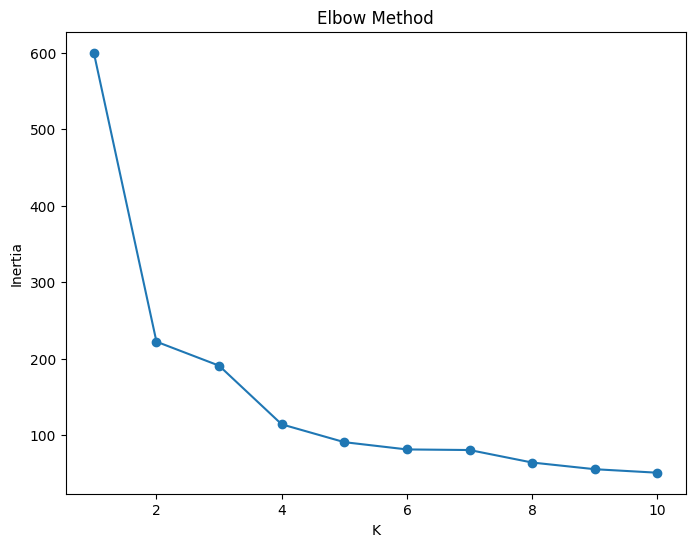

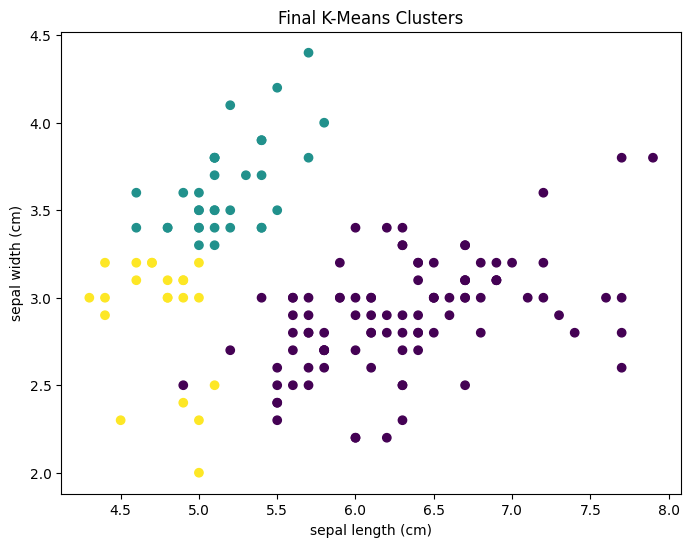

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load Dataset
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

# Elbow Method
wss = []

for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    wss.append(model.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1,11), wss, marker="o")
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

# Final Model
kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

# Visualization
plt.figure(figsize=(8,6))

plt.scatter(
    df.iloc[:,0],
    df.iloc[:,1],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("Final K-Means Clusters")
plt.show()

print(df.head())